# VisionGuard AI — Inference Demo

End-to-end inference, anomaly scoring, visualization, defect localization, evaluation, and artifact export for the five selected MVTec AD categories.

This notebook is designed to run after the VisionGuard AI dataset-preparation and CNN autoencoder training workflow. It automatically discovers the prepared dataset, trained models, and available threshold artifacts instead of requiring manual absolute paths.


## Objectives

- Discover the prepared five-category dataset automatically.
- Discover and validate trained TensorFlow/Keras autoencoder models.
- Discover precomputed anomaly thresholds when available.
- Fall back to deterministic threshold calibration from normal images when required.
- Run single-image and batch reconstruction inference.
- Calculate reconstruction-based anomaly scores, margins, and ratios.
- Evaluate image-level predictions.
- Generate ROC and precision-recall analysis where valid.
- Perform pixel-level defect localization on representative samples.
- Compare predicted masks with ground-truth masks.
- Produce publication-ready Matplotlib and Plotly figures.
- Save every visualization using its chart title inside the `images` folder.
- Save clean inference tables inside the `tables` folder without exposing path columns in displayed outputs.


## Workflow

The notebook is intentionally split into small execution units. Imports and reusable helpers are defined once and reused throughout the notebook. Re-running later cells should not redefine the same functions.


## Environment and package setup


In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
    "cv2": "opencv-python",
    "plotly": "plotly",
    "kaleido": "kaleido",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
}

missing_packages = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
        )
        print("Missing dependencies installed successfully.")
    except Exception as exc:
        raise RuntimeError(
            "Dependency installation failed. Resolve the package installation issue and rerun this cell."
        ) from exc
else:
    print("All required dependencies are already available.")


All required dependencies are already available.


## Imports

All library imports are centralized here. Later cells reuse these imported modules rather than importing the same libraries again.


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import math
import random
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from PIL import Image, ImageFile
from IPython.display import display

try:
    from google.colab import files as colab_files
except Exception:
    colab_files = None

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

import tensorflow as tf
from tensorflow import keras

ImageFile.LOAD_TRUNCATED_IMAGES = False
warnings.filterwarnings("ignore")


## Reproducibility and inference configuration


In [3]:
SEED = 42

CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_SIZE = (128, 128)
IMAGE_CHANNELS = 3

PRIMARY_THRESHOLD_PERCENTILE = 99.0
PIXEL_THRESHOLD_PERCENTILE = 99.5

BATCH_SIZE = 32
VALIDATION_SAMPLE_LIMIT = 40
LOCALIZATION_SAMPLE_LIMIT = 3
DEMO_SAMPLE_LIMIT = 2
TIMING_SAMPLE_LIMIT = 10
THRESHOLD_MULTIPLIERS = [0.75, 0.90, 1.00, 1.10, 1.25]

EVALUATE_FULL_TEST_SET = True
USE_CACHE_FOR_IMAGES = False

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [4]:
gpu_devices = tf.config.list_physical_devices("GPU")

inference_backend = "GPU" if gpu_devices else "CPU"

print("Categories configured:", len(CATEGORIES))
print("Inference resolution:", f"{IMAGE_SIZE[0]} × {IMAGE_SIZE[1]}")
print("Batch size:", BATCH_SIZE)
print("Inference backend:", inference_backend)


Categories configured: 5
Inference resolution: 128 × 128
Batch size: 32
Inference backend: GPU


## Output folders

All static PNG figures and Plotly HTML figures are written to `images`. Clean tabular artifacts are written to `tables`.


In [5]:
IMAGE_DIR = Path("images")
TABLE_DIR = Path("tables")

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## Visualization helpers


In [6]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

def is_image_file(path):
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def image_files(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return []
    return sorted(
        path for path in folder.rglob("*")
        if is_image_file(path)
    )


def sanitize_filename(title):
    cleaned = re.sub(r"[^A-Za-z0-9]+", "_", str(title))
    cleaned = re.sub(r"_+", "_", cleaned).strip("_")
    return cleaned or "visualization"


In [7]:
def save_mpl(fig, title, dpi=220):
    filename = sanitize_filename(title)
    output_file = IMAGE_DIR / f"{filename}.png"
    fig.savefig(
        output_file,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )
    return output_file


def save_plotly(fig, title, width=1400, height=850, scale=2):
    filename = sanitize_filename(title)
    html_file = IMAGE_DIR / f"{filename}.html"
    png_file = IMAGE_DIR / f"{filename}.png"

    fig.write_html(
        html_file,
        include_plotlyjs="cdn",
    )

    png_saved = False

    try:
        fig.write_image(
            png_file,
            format="png",
            width=width,
            height=height,
            scale=scale,
        )
        png_saved = True
    except Exception as exc:
        print("Plotly PNG export is unavailable in the current browser runtime.")
        print(f"Export warning: {type(exc).__name__}.")

    return {
        "HTML": True,
        "PNG": png_saved,
    }


def finalize_mpl(fig, title, dpi=220):
    save_mpl(fig, title, dpi=dpi)
    plt.show()
    plt.close(fig)


def finalize_plotly(fig, title, width=1400, height=850, scale=2):
    fig.update_layout(
        title=title,
        width=width,
        height=height,
        margin=dict(l=60, r=40, t=95, b=60),
    )

    result = save_plotly(
        fig,
        title,
        width=width,
        height=height,
        scale=scale,
    )

    fig.show()

    if result["PNG"]:
        print("Plotly figure exported successfully.")
    else:
        print("Plotly interactive figure exported; static PNG export needs browser support.")

    return result


## Plotly static export readiness

Kaleido v1+ uses a Chrome/Chromium runtime for static PNG export. The notebook attempts to initialize the supported browser automatically without printing its location.


In [8]:
plotly_static_export_ready = False

try:
    pio.get_chrome()
    plotly_static_export_ready = True
except Exception:
    try:
        pio.get_chrome_sync()
        plotly_static_export_ready = True
    except Exception:
        plotly_static_export_ready = False

print(
    "Plotly static PNG export ready:",
    plotly_static_export_ready,
)


Plotly static PNG export ready: True


## Automatic dataset discovery


In [9]:
def find_named_directories(name, roots=None):
    roots = [Path.cwd()] if roots is None else [Path(root) for root in roots]

    excluded = {
        ".git",
        "__pycache__",
        ".ipynb_checkpoints",
        "node_modules",
        ".cache",
    }

    matches = []

    for root in roots:
        direct = root / name
        if direct.is_dir():
            matches.append(direct)

        try:
            for candidate in root.rglob(name):
                if candidate.is_dir() and not any(
                    part in excluded for part in candidate.parts
                ):
                    matches.append(candidate)
        except Exception:
            continue

    return sorted(set(matches))


In [10]:
def dataset_contract_score(candidate):
    score = 0

    for category in CATEGORIES:
        category_root = candidate / category

        if category_root.is_dir():
            score += 1

        for split in ("train", "test", "ground_truth"):
            if (category_root / split).is_dir():
                score += 1

    return score


In [11]:
dataset_candidates = find_named_directories("visionguard_data")

if not dataset_candidates:
    raise FileNotFoundError(
        "Prepared VisionGuard AI dataset was not discovered. "
        "Run the dataset preparation notebook first."
    )

DATASET_ROOT = max(
    dataset_candidates,
    key=dataset_contract_score,
)

print("Prepared dataset discovered successfully.")


Prepared dataset discovered successfully.


## Dataset availability


In [12]:
availability_rows = []

for category in CATEGORIES:
    category_root = DATASET_ROOT / category

    availability_rows.append({
        "Category": category,
        "Available": category_root.is_dir(),
        "Train": (category_root / "train").is_dir(),
        "Test": (category_root / "test").is_dir(),
        "Ground Truth": (category_root / "ground_truth").is_dir(),
    })

availability_df = pd.DataFrame(availability_rows)
display(availability_df)


,Category,Available,Train,Test,Ground Truth
0,screw,True,True,True,True
1,bottle,True,True,True,True
2,capsule,True,True,True,True
3,metal_nut,True,True,True,True
4,hazelnut,True,True,True,True


In [13]:
available_categories = availability_df.loc[
    availability_df["Test"].astype(bool),
    "Category",
].tolist()

missing_categories = [
    category
    for category in CATEGORIES
    if category not in available_categories
]

print("Available categories:", len(available_categories))

if missing_categories:
    print("Missing categories:", ", ".join(missing_categories))
else:
    print("All requested categories are available.")


Available categories: 5
All requested categories are available.


## Test manifest construction


In [14]:
def collect_test_records(category):
    records = []

    test_root = DATASET_ROOT / category / "test"

    if not test_root.is_dir():
        return records

    defect_directories = sorted(
        directory for directory in test_root.iterdir()
        if directory.is_dir()
    )

    for defect_directory in defect_directories:
        defect_type = defect_directory.name

        for image_path in image_files(defect_directory):
            records.append({
                "Category": category,
                "Defect Type": defect_type,
                "File": image_path.name,
                "Image Key": image_path.stem,
                "Ground Truth Label": 0 if defect_type.lower() == "good" else 1,
                "Image Path": image_path,
            })

    return records


In [15]:
manifest_records = []

for category in available_categories:
    manifest_records.extend(
        collect_test_records(category)
    )

test_manifest_df = pd.DataFrame(manifest_records)

if test_manifest_df.empty:
    raise RuntimeError(
        "No test images were discovered for the available categories."
    )

print("Test images discovered:", len(test_manifest_df))


Test images discovered: 600


In [16]:
manifest_summary_df = (
    test_manifest_df
    .groupby(
        ["Category", "Defect Type", "Ground Truth Label"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Images"})
)

manifest_summary_df["Class"] = np.where(
    manifest_summary_df["Ground Truth Label"].eq(0),
    "Normal",
    "Defective",
)

display(manifest_summary_df)


,Category,Defect Type,Ground Truth Label,Images,Class
0,bottle,broken_large,1,20,Defective
1,bottle,broken_small,1,22,Defective
2,bottle,contamination,1,21,Defective
3,bottle,good,0,20,Normal
4,capsule,crack,1,23,Defective
5,capsule,faulty_imprint,1,22,Defective
6,capsule,good,0,23,Normal
7,capsule,poke,1,21,Defective
8,capsule,scratch,1,23,Defective
9,capsule,squeeze,1,20,Defective


## Test-set distribution


In [17]:
class_distribution_df = (
    test_manifest_df
    .assign(
        Class=np.where(
            test_manifest_df["Ground Truth Label"].eq(0),
            "Normal",
            "Defective",
        )
    )
    .groupby(
        ["Category", "Class"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Images"})
)

display(class_distribution_df)


,Category,Class,Images
0,bottle,Defective,63
1,bottle,Normal,20
2,capsule,Defective,109
3,capsule,Normal,23
4,hazelnut,Defective,70
5,hazelnut,Normal,40
6,metal_nut,Defective,93
7,metal_nut,Normal,22
8,screw,Defective,119
9,screw,Normal,41


In [18]:
fig = px.bar(
    class_distribution_df,
    x="Category",
    y="Images",
    color="Class",
    barmode="group",
    text="Images",
    title="VisionGuard AI — Normal vs Defective Test Distribution",
    template="plotly_white",
)

fig.update_traces(textposition="outside")

finalize_plotly(
    fig,
    "VisionGuard AI — Normal vs Defective Test Distribution",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [19]:
fig = px.bar(
    manifest_summary_df,
    x="Category",
    y="Images",
    color="Defect Type",
    barmode="stack",
    text="Images",
    title="VisionGuard AI — Test Images by Defect Type",
    template="plotly_white",
)

fig.update_traces(textposition="inside")

finalize_plotly(
    fig,
    "VisionGuard AI — Test Images by Defect Type",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Trained model discovery


In [20]:
def find_model_candidates(category):
    candidates = []

    search_roots = [Path.cwd()]

    for root in search_roots:
        try:
            for pattern in ("best_model.keras", "*.keras", "*.h5"):
                for candidate in root.rglob(pattern):
                    if not candidate.is_file():
                        continue

                    parent_name = candidate.parent.name.lower()
                    stem_name = candidate.stem.lower()

                    if category.lower() in parent_name or category.lower() in stem_name:
                        candidates.append(candidate)
        except Exception:
            continue

    return sorted(set(candidates))


In [21]:
model_registry = {}
model_status_rows = []

for category in available_categories:
    candidates = find_model_candidates(category)

    if candidates:
        preferred = [
            candidate for candidate in candidates
            if candidate.name == "best_model.keras"
        ]

        selected = preferred[0] if preferred else candidates[0]

        model_registry[category] = selected

        model_status_rows.append({
            "Category": category,
            "Model Available": True,
            "Candidates": len(candidates),
        })
    else:
        model_status_rows.append({
            "Category": category,
            "Model Available": False,
            "Candidates": 0,
        })

model_status_df = pd.DataFrame(model_status_rows)
display(model_status_df)


,Category,Model Available,Candidates
0,screw,True,3
1,bottle,True,3
2,capsule,True,3
3,metal_nut,True,3
4,hazelnut,True,3


In [22]:
missing_models = [
    category
    for category in available_categories
    if category not in model_registry
]

if missing_models:
    print("Categories without a discoverable model:", ", ".join(missing_models))
else:
    print("A trained model was discovered for every available category.")


A trained model was discovered for every available category.


## Load trained models once


In [23]:
best_models = {}
model_load_rows = []

for category, model_file in model_registry.items():
    try:
        model = keras.models.load_model(
            model_file,
            compile=False,
        )

        best_models[category] = model

        model_load_rows.append({
            "Category": category,
            "Loaded": True,
            "Layers": len(model.layers),
            "Parameters": int(model.count_params()),
        })
    except Exception as exc:
        model_load_rows.append({
            "Category": category,
            "Loaded": False,
            "Layers": np.nan,
            "Parameters": np.nan,
        })
        print(
            f"{category}: model loading failed ({type(exc).__name__})."
        )

model_load_df = pd.DataFrame(model_load_rows)
display(model_load_df)

if not best_models:
    raise RuntimeError("No trained TensorFlow/Keras models could be loaded.")


I0000 00:00:1790965648.078658  358293 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


,Category,Loaded,Layers,Parameters
0,screw,True,21,778371
1,bottle,True,21,778371
2,capsule,True,21,778371
3,metal_nut,True,21,778371
4,hazelnut,True,21,778371


In [24]:
model_metadata_df = pd.DataFrame([
    {
        "Category": category,
        "Layers": len(model.layers),
        "Parameters": int(model.count_params()),
        "Input Shape": tuple(model.input_shape),
        "Output Shape": tuple(model.output_shape),
    }
    for category, model in best_models.items()
])

display(model_metadata_df)


,Category,Layers,Parameters,Input Shape,Output Shape
0,screw,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
1,bottle,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
2,capsule,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
3,metal_nut,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
4,hazelnut,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"


In [25]:
expected_shape = (*IMAGE_SIZE, IMAGE_CHANNELS)

contract_rows = []

for category, model in best_models.items():
    input_shape = tuple(model.input_shape[1:])
    output_shape = tuple(model.output_shape[1:])

    contract_rows.append({
        "Category": category,
        "Expected Shape": expected_shape,
        "Input Shape": input_shape,
        "Output Shape": output_shape,
        "Input Valid": input_shape == expected_shape,
        "Output Valid": output_shape == expected_shape,
    })

model_contract_df = pd.DataFrame(contract_rows)

display(model_contract_df)

if not model_contract_df.empty:
    valid_contract = model_contract_df[
        ["Input Valid", "Output Valid"]
    ].to_numpy().all()

    if not valid_contract:
        raise ValueError(
            "At least one loaded model does not match the expected inference tensor contract."
        )


,Category,Expected Shape,Input Shape,Output Shape,Input Valid,Output Valid
0,screw,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
1,bottle,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
2,capsule,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
3,metal_nut,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
4,hazelnut,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True


In [26]:
trainable_parameter_rows = []

for category, model in best_models.items():
    trainable = int(
        sum(
            np.prod(variable.shape)
            for variable in model.trainable_variables
        )
    )

    total = int(model.count_params())

    trainable_parameter_rows.append({
        "Category": category,
        "Trainable Parameters": trainable,
        "Non-Trainable Parameters": total - trainable,
        "Total Parameters": total,
    })

parameter_df = pd.DataFrame(trainable_parameter_rows)
display(parameter_df)


,Category,Trainable Parameters,Non-Trainable Parameters,Total Parameters
0,screw,777475,896,778371
1,bottle,777475,896,778371
2,capsule,777475,896,778371
3,metal_nut,777475,896,778371
4,hazelnut,777475,896,778371


In [27]:
fig = px.bar(
    parameter_df,
    x="Category",
    y="Total Parameters",
    text="Total Parameters",
    title="VisionGuard AI — Autoencoder Parameter Counts",
    template="plotly_white",
)

fig.update_traces(
    texttemplate="%{y:,}",
    textposition="outside",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Autoencoder Parameter Counts",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Image and ground-truth processing


In [28]:
def load_rgb_array(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS,
        )
        return np.asarray(
            image,
            dtype=np.float32,
        ) / 255.0


def load_gray_mask(mask_path):
    if mask_path is None:
        return None

    mask_path = Path(mask_path)

    if not mask_path.is_file():
        return None

    with Image.open(mask_path) as mask:
        mask = mask.convert("L")
        mask = mask.resize(
            IMAGE_SIZE,
            Image.Resampling.NEAREST,
        )
        return np.asarray(mask) > 0


In [29]:
def locate_ground_truth(category, defect_type, filename):
    if str(defect_type).lower() == "good":
        return None

    ground_truth_root = (
        DATASET_ROOT
        / category
        / "ground_truth"
        / defect_type
    )

    if not ground_truth_root.is_dir():
        return None

    stem = Path(filename).stem

    preferred = [
        ground_truth_root / f"{stem}_mask.png",
        ground_truth_root / f"{stem}_mask.jpg",
        ground_truth_root / f"{stem}_mask.jpeg",
    ]

    for candidate in preferred:
        if candidate.is_file():
            return candidate

    matches = sorted(
        path for path in image_files(ground_truth_root)
        if path.stem.startswith(stem)
    )

    return matches[0] if matches else None


In [30]:
test_manifest_df["Ground Truth Path"] = [
    locate_ground_truth(
        row["Category"],
        row["Defect Type"],
        row["File"],
    )
    for _, row in test_manifest_df.iterrows()
]

test_manifest_df["Ground Truth Available"] = (
    test_manifest_df["Ground Truth Path"].notna()
)

display(
    test_manifest_df[
        ["Category", "Defect Type", "Ground Truth Available"]
    ]
    .groupby(
        ["Category", "Defect Type"],
        as_index=False,
    )
    .agg(
        Images=("Category", "size"),
        Ground_Truth=("Ground Truth Available", "sum"),
    )
)


,Category,Defect Type,Images,Ground_Truth
0,bottle,broken_large,20,20
1,bottle,broken_small,22,22
2,bottle,contamination,21,21
3,bottle,good,20,0
4,capsule,crack,23,23
5,capsule,faulty_imprint,22,22
6,capsule,good,23,0
7,capsule,poke,21,21
8,capsule,scratch,23,23
9,capsule,squeeze,20,20


In [31]:
ground_truth_coverage_df = (
    test_manifest_df
    .groupby("Category", as_index=False)
    .agg(
        Test_Images=("File", "count"),
        Ground_Truth_Images=("Ground Truth Available", "sum"),
    )
)

ground_truth_coverage_df["Coverage (%)"] = (
    ground_truth_coverage_df["Ground_Truth_Images"]
    / ground_truth_coverage_df["Test_Images"]
    * 100
)

display(ground_truth_coverage_df.round(2))


,Category,Test_Images,Ground_Truth_Images,Coverage (%)
0,bottle,83,63,75.90
1,capsule,132,109,82.58
2,hazelnut,110,70,63.64
3,metal_nut,115,93,80.87
4,screw,160,119,74.38


In [32]:
fig = px.bar(
    ground_truth_coverage_df,
    x="Category",
    y="Coverage (%)",
    text="Coverage (%)",
    title="VisionGuard AI — Ground-Truth Availability by Category",
    template="plotly_white",
)

fig.update_traces(
    texttemplate="%{y:.1f}%",
    textposition="outside",
)

fig.update_yaxes(range=[0, 105])

finalize_plotly(
    fig,
    "VisionGuard AI — Ground-Truth Availability by Category",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Reconstruction and anomaly-score functions


In [33]:
def reconstruction_metrics(original, reconstruction):
    original = np.asarray(original, dtype=np.float32)
    reconstruction = np.asarray(reconstruction, dtype=np.float32)

    difference = original - reconstruction
    absolute_error = np.abs(difference)
    squared_error = np.square(difference)

    mae_map = np.mean(absolute_error, axis=-1)
    mse_map = np.mean(squared_error, axis=-1)

    return {
        "mse": float(np.mean(squared_error)),
        "mae": float(np.mean(absolute_error)),
        "max_abs_error": float(np.max(absolute_error)),
        "mae_map": mae_map,
        "mse_map": mse_map,
    }


In [34]:
def predict_image(model, image_path):
    image = load_rgb_array(image_path)

    reconstruction = model.predict(
        image[None, ...],
        verbose=0,
    )[0]

    reconstruction = np.clip(
        reconstruction,
        0.0,
        1.0,
    )

    metrics = reconstruction_metrics(
        image,
        reconstruction,
    )

    return image, reconstruction, metrics


In [35]:
def predict_batch(model, image_paths, batch_size=BATCH_SIZE):
    images = np.stack(
        [
            load_rgb_array(path)
            for path in image_paths
        ],
        axis=0,
    )

    reconstructions = model.predict(
        images,
        batch_size=batch_size,
        verbose=0,
    )

    reconstructions = np.clip(
        reconstructions,
        0.0,
        1.0,
    )

    metrics = [
        reconstruction_metrics(
            image,
            reconstruction,
        )
        for image, reconstruction in zip(
            images,
            reconstructions,
        )
    ]

    return images, reconstructions, metrics


In [36]:
def safe_float(value, default=np.nan):
    try:
        return float(value)
    except Exception:
        return default


## Normal-image threshold calibration


In [37]:
def discover_normal_validation_images(category):
    candidates = []

    for folder_name in ("validation", "val"):
        validation_root = (
            DATASET_ROOT
            / folder_name
            / category
            / "good"
        )
        candidates.extend(image_files(validation_root))

    if candidates:
        return sorted(candidates)[:VALIDATION_SAMPLE_LIMIT]

    train_good_root = (
        DATASET_ROOT
        / category
        / "train"
        / "good"
    )

    train_good = image_files(train_good_root)

    if len(train_good) <= VALIDATION_SAMPLE_LIMIT:
        return train_good

    rng = np.random.default_rng(SEED)
    selected_indices = rng.choice(
        len(train_good),
        size=VALIDATION_SAMPLE_LIMIT,
        replace=False,
    )

    return sorted(
        train_good[index]
        for index in selected_indices
    )


In [38]:
validation_registry = {
    category: discover_normal_validation_images(category)
    for category in best_models
}

validation_counts_df = pd.DataFrame([
    {
        "Category": category,
        "Normal Calibration Images": len(paths),
    }
    for category, paths in validation_registry.items()
])

display(validation_counts_df)


,Category,Normal Calibration Images
0,screw,40
1,bottle,40
2,capsule,40
3,metal_nut,40
4,hazelnut,40


In [39]:
validation_error_registry = {}

for category, image_paths in validation_registry.items():
    if not image_paths:
        continue

    values = []

    for image_path in image_paths:
        _, _, metrics = predict_image(
            best_models[category],
            image_path,
        )
        values.append(metrics["mse"])

    validation_error_registry[category] = np.asarray(
        values,
        dtype=np.float64,
    )

print(
    "Categories with normal calibration scores:",
    len(validation_error_registry),
)


2026-10-02 18:27:30.754093: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-02 18:27:35.840559: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Categories with normal calibration scores: 5


## Precomputed threshold discovery


In [40]:
def discover_threshold_artifact():
    candidate_names = [
        "primary_thresholds.csv",
        "thresholds.csv",
        "anomaly_thresholds.csv",
    ]

    candidates = []

    for name in candidate_names:
        try:
            candidates.extend(
                path for path in Path.cwd().rglob(name)
                if path.is_file()
            )
        except Exception:
            continue

    candidates = sorted(set(candidates))

    return candidates[0] if candidates else None


threshold_artifact = discover_threshold_artifact()
print("Precomputed threshold artifact found:", bool(threshold_artifact))


Precomputed threshold artifact found: True


In [41]:
def load_threshold_artifact(path):
    if path is None:
        return {}

    try:
        frame = pd.read_csv(path)
    except Exception:
        return {}

    required = {"Category", "Threshold"}

    if not required.issubset(frame.columns):
        return {}

    return dict(
        zip(
            frame["Category"].astype(str),
            frame["Threshold"].astype(float),
        )
    )


threshold_map = load_threshold_artifact(
    threshold_artifact
)

print("Precomputed thresholds loaded:", len(threshold_map))


Precomputed thresholds loaded: 5


In [42]:
for category, values in validation_error_registry.items():
    if category not in threshold_map and len(values):
        threshold_map[category] = float(
            np.percentile(
                values,
                PRIMARY_THRESHOLD_PERCENTILE,
            )
        )

threshold_rows = [
    {
        "Category": category,
        "Threshold": threshold_map[category],
        "Method": (
            "Precomputed artifact"
            if threshold_artifact is not None and category in load_threshold_artifact(threshold_artifact)
            else f"Normal calibration P{PRIMARY_THRESHOLD_PERCENTILE:g}"
        ),
    }
    for category in best_models
    if category in threshold_map
]

threshold_df = pd.DataFrame(threshold_rows)

display(
    threshold_df.round(8)
)

if threshold_df.empty:
    raise RuntimeError(
        "No image-level anomaly thresholds are available."
    )


,Category,Threshold,Method
0,screw,0.024788,Precomputed artifact
1,bottle,0.107541,Precomputed artifact
2,capsule,0.066382,Precomputed artifact
3,metal_nut,0.026352,Precomputed artifact
4,hazelnut,0.008426,Precomputed artifact


In [43]:
threshold_reference_rows = []

for category, values in validation_error_registry.items():
    if len(values):
        threshold_reference_rows.append({
            "Category": category,
            "P50": np.percentile(values, 50),
            "P90": np.percentile(values, 90),
            "P95": np.percentile(values, 95),
            "P99": np.percentile(values, 99),
            "Mean": np.mean(values),
            "Std": np.std(values),
        })

threshold_reference_df = pd.DataFrame(
    threshold_reference_rows
)

display(
    threshold_reference_df.round(8)
)


,Category,P50,P90,P95,P99,Mean,Std
0,screw,0.021816,0.024806,0.025435,0.027643,0.022196,0.001983
1,bottle,0.106213,0.107199,0.107460,0.107624,0.105870,0.001206
2,capsule,0.061449,0.063656,0.065527,0.071822,0.061279,0.003222
3,metal_nut,0.017336,0.020879,0.021332,0.025422,0.017893,0.002235
4,hazelnut,0.005201,0.007658,0.008669,0.009202,0.005505,0.001448


In [44]:
validation_error_plot_df = pd.DataFrame([
    {
        "Category": category,
        "Reconstruction Error": value,
    }
    for category, values in validation_error_registry.items()
    for value in values
])

fig = px.box(
    validation_error_plot_df,
    x="Category",
    y="Reconstruction Error",
    points=False,
    title="VisionGuard AI — Normal Calibration Reconstruction Error",
    template="plotly_white",
)

fig.update_layout(
    yaxis_title="Reconstruction MSE"
)

finalize_plotly(
    fig,
    "VisionGuard AI — Normal Calibration Reconstruction Error",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [45]:
threshold_percentile_plot_df = threshold_reference_df.melt(
    id_vars="Category",
    value_vars=["P50", "P90", "P95", "P99"],
    var_name="Percentile",
    value_name="Reconstruction Error",
)

fig = px.line(
    threshold_percentile_plot_df,
    x="Percentile",
    y="Reconstruction Error",
    color="Category",
    markers=True,
    title="VisionGuard AI — Normal Calibration Error Percentiles",
    template="plotly_white",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Normal Calibration Error Percentiles",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [46]:
fig = px.bar(
    threshold_df,
    x="Category",
    y="Threshold",
    text="Threshold",
    title="VisionGuard AI — Category-Specific Anomaly Thresholds",
    template="plotly_white",
)

fig.update_traces(
    texttemplate="%{y:.6f}",
    textposition="outside",
)

fig.update_layout(
    yaxis_title="Anomaly Threshold",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Category-Specific Anomaly Thresholds",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Image-level scoring helpers


In [47]:
def anomaly_label(category, score):
    threshold = threshold_map.get(category, np.nan)

    if not np.isfinite(threshold):
        return "UNKNOWN"

    return (
        "ANOMALY"
        if float(score) > float(threshold)
        else "NORMAL"
    )


def anomaly_margin(category, score):
    threshold = threshold_map.get(category, np.nan)
    return float(score) - float(threshold)


def anomaly_ratio(category, score):
    threshold = threshold_map.get(category, np.nan)

    if not np.isfinite(threshold) or threshold == 0:
        return np.nan

    return float(score) / float(threshold)


In [48]:
def result_row(
    category,
    defect_type,
    file_name,
    image_path,
    metrics,
):
    score = metrics["mse"]
    threshold = threshold_map.get(category, np.nan)

    return {
        "Category": category,
        "Defect Type": defect_type,
        "File": file_name,
        "Ground Truth Label": 0 if str(defect_type).lower() == "good" else 1,
        "Reconstruction Error": score,
        "MAE": metrics["mae"],
        "Maximum Absolute Error": metrics["max_abs_error"],
        "Threshold": threshold,
        "Threshold Ratio": anomaly_ratio(category, score),
        "Anomaly Margin": anomaly_margin(category, score),
        "Prediction": anomaly_label(category, score),
        "Correct": (
            anomaly_label(category, score)
            == (
                "NORMAL"
                if str(defect_type).lower() == "good"
                else "ANOMALY"
            )
        ),
        "Image Path": image_path,
    }


## Full or limited test inference


In [49]:
def select_inference_manifest(category):
    subset = test_manifest_df[
        test_manifest_df["Category"].eq(category)
    ].copy()

    if EVALUATE_FULL_TEST_SET:
        return subset.reset_index(drop=True)

    return subset.head(
        TIMING_SAMPLE_LIMIT
    ).reset_index(drop=True)


In [50]:
score_rows = []

for category, model in best_models.items():
    category_manifest = select_inference_manifest(category)

    if category_manifest.empty:
        continue

    image_paths = category_manifest["Image Path"].tolist()

    for start_index in range(0, len(image_paths), BATCH_SIZE):
        batch_manifest = category_manifest.iloc[
            start_index:start_index + BATCH_SIZE
        ]

        batch_paths = batch_manifest["Image Path"].tolist()

        _, _, batch_metrics = predict_batch(
            model,
            batch_paths,
            batch_size=BATCH_SIZE,
        )

        for (_, row), metrics in zip(
            batch_manifest.iterrows(),
            batch_metrics,
        ):
            score_rows.append(
                result_row(
                    category=row["Category"],
                    defect_type=row["Defect Type"],
                    file_name=row["File"],
                    image_path=row["Image Path"],
                    metrics=metrics,
                )
            )

score_results_df = pd.DataFrame(score_rows)

if score_results_df.empty:
    raise RuntimeError(
        "No test images were successfully scored."
    )

print(
    "Images scored:",
    len(score_results_df),
)


2026-10-02 18:28:07.394043: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-02 18:28:14.463436: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Images scored: 600


2026-10-02 18:28:23.185212: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [51]:
display_columns = [
    "Category",
    "Defect Type",
    "File",
    "Ground Truth Label",
    "Reconstruction Error",
    "Threshold",
    "Anomaly Margin",
    "Prediction",
    "Correct",
]

display(
    score_results_df[display_columns]
    .head(20)
    .round(6)
)


,Category,Defect Type,File,Ground Truth Label,Reconstruction Error,Threshold,Anomaly Margin,Prediction,Correct
0,screw,good,000.png,0,0.026037,0.024788,0.001249,ANOMALY,False
1,screw,good,001.png,0,0.024726,0.024788,-0.000062,NORMAL,True
2,screw,good,002.png,0,0.025275,0.024788,0.000487,ANOMALY,False
3,screw,good,003.png,0,0.025869,0.024788,0.001081,ANOMALY,False
4,screw,good,004.png,0,0.022443,0.024788,-0.002345,NORMAL,True
5,screw,good,005.png,0,0.025287,0.024788,0.000500,ANOMALY,False
6,screw,good,006.png,0,0.025534,0.024788,0.000747,ANOMALY,False
7,screw,good,007.png,0,0.030047,0.024788,0.005259,ANOMALY,False
8,screw,good,008.png,0,0.026948,0.024788,0.002160,ANOMALY,False
9,screw,good,009.png,0,0.025595,0.024788,0.000807,ANOMALY,False


In [52]:
score_summary_df = (
    score_results_df
    .groupby("Category", as_index=False)
    .agg(
        Images=("File", "count"),
        Normal=("Ground Truth Label", lambda s: int((s == 0).sum())),
        Defective=("Ground Truth Label", lambda s: int((s == 1).sum())),
        Mean_Score=("Reconstruction Error", "mean"),
        Median_Score=("Reconstruction Error", "median"),
        Mean_Margin=("Anomaly Margin", "mean"),
        Mean_Ratio=("Threshold Ratio", "mean"),
        Accuracy=("Correct", "mean"),
    )
)

score_summary_df["Accuracy (%)"] = (
    score_summary_df["Accuracy"] * 100
)

display(
    score_summary_df.round(5)
)


,Category,Images,Normal,Defective,Mean_Score,Median_Score,Mean_Margin,Mean_Ratio,Accuracy,Accuracy (%)
0,bottle,83,20,63,0.10460,0.10507,-0.00295,0.97261,0.26506,26.50602
1,capsule,132,23,109,0.05993,0.06106,-0.00646,0.90275,0.18939,18.93939
2,hazelnut,110,40,70,0.00510,0.00450,-0.00333,0.60493,0.44545,44.54545
3,metal_nut,115,22,93,0.01656,0.01621,-0.00980,0.62826,0.19130,19.13043
4,screw,160,41,119,0.02223,0.02161,-0.00256,0.89684,0.12500,12.50000


In [53]:
fig = px.box(
    score_results_df,
    x="Category",
    y="Reconstruction Error",
    color="Prediction",
    points=False,
    title="VisionGuard AI — Reconstruction Error by Category",
    template="plotly_white",
)

fig.update_layout(
    yaxis_title="Reconstruction MSE"
)

finalize_plotly(
    fig,
    "VisionGuard AI — Reconstruction Error by Category",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [54]:
fig = px.histogram(
    score_results_df,
    x="Reconstruction Error",
    color="Category",
    facet_row="Category",
    histnorm="probability density",
    title="VisionGuard AI — Reconstruction Error Distributions",
    template="plotly_white",
)

fig.update_layout(
    height=1200,
    showlegend=False,
)

finalize_plotly(
    fig,
    "VisionGuard AI — Reconstruction Error Distributions",
    height=1200,
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [55]:
fig = px.histogram(
    score_results_df,
    x="Anomaly Margin",
    color="Category",
    facet_row="Category",
    histnorm="probability density",
    title="VisionGuard AI — Anomaly Margin Distributions",
    template="plotly_white",
)

fig.update_layout(
    height=1200,
    showlegend=False,
)

finalize_plotly(
    fig,
    "VisionGuard AI — Anomaly Margin Distributions",
    height=1200,
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [56]:
ratio_plot_df = score_results_df[
    np.isfinite(score_results_df["Threshold Ratio"])
].copy()

fig = px.box(
    ratio_plot_df,
    x="Category",
    y="Threshold Ratio",
    color="Prediction",
    points=False,
    title="VisionGuard AI — Anomaly Score to Threshold Ratio",
    template="plotly_white",
)

fig.add_hline(
    y=1.0,
    line_dash="dash",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Anomaly Score to Threshold Ratio",
)


Wait expired, Browser is being closed by watchdog.


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Image-level evaluation


In [57]:
classification_rows = []

for category, group in score_results_df.groupby("Category"):
    y_true = group["Ground Truth Label"].to_numpy()
    y_pred = (
        group["Prediction"]
        .map({"NORMAL": 0, "ANOMALY": 1})
        .to_numpy()
    )
    scores = group["Reconstruction Error"].to_numpy()

    classification_rows.append({
        "Category": category,
        "Samples": len(group),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": (
            roc_auc_score(y_true, scores)
            if len(np.unique(y_true)) == 2
            else np.nan
        ),
        "Average Precision": (
            average_precision_score(y_true, scores)
            if len(np.unique(y_true)) == 2
            else np.nan
        ),
    })

metrics_df = pd.DataFrame(classification_rows)

display(
    metrics_df.round(4)
)


,Category,Samples,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,bottle,83,0.2651,1.0000,0.0317,0.0615,0.4833,0.7985
1,capsule,132,0.1894,1.0000,0.0183,0.0360,0.4878,0.8286
2,hazelnut,110,0.4455,1.0000,0.1286,0.2278,0.7407,0.8563
3,metal_nut,115,0.1913,0.0000,0.0000,0.0000,0.2253,0.6794
4,screw,160,0.1250,0.1818,0.0504,0.0789,0.0486,0.5423


In [58]:
metrics_long_df = metrics_df.melt(
    id_vars="Category",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision",
    ],
    var_name="Metric",
    value_name="Value",
)

fig = px.bar(
    metrics_long_df,
    x="Category",
    y="Value",
    color="Metric",
    barmode="group",
    title="VisionGuard AI — Image-Level Inference Metrics",
    template="plotly_white",
)

fig.update_yaxes(range=[0, 1])

finalize_plotly(
    fig,
    "VisionGuard AI — Image-Level Inference Metrics",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [59]:
confusion_rows = []

for category, group in score_results_df.groupby("Category"):
    y_true = group["Ground Truth Label"].to_numpy()
    y_pred = (
        group["Prediction"]
        .map({"NORMAL": 0, "ANOMALY": 1})
        .to_numpy()
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    confusion_rows.append({
        "Category": category,
        "TN": int(matrix[0, 0]),
        "FP": int(matrix[0, 1]),
        "FN": int(matrix[1, 0]),
        "TP": int(matrix[1, 1]),
    })

confusion_df = pd.DataFrame(confusion_rows)

display(confusion_df)


,Category,TN,FP,FN,TP
0,bottle,20,0,61,2
1,capsule,23,0,107,2
2,hazelnut,40,0,61,9
3,metal_nut,22,0,93,0
4,screw,14,27,113,6


In [60]:
confusion_long_df = confusion_df.melt(
    id_vars="Category",
    var_name="Outcome",
    value_name="Images",
)

fig = px.bar(
    confusion_long_df,
    x="Category",
    y="Images",
    color="Outcome",
    barmode="group",
    title="VisionGuard AI — Image-Level Confusion Outcomes",
    template="plotly_white",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Image-Level Confusion Outcomes",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## ROC and precision-recall analysis


In [61]:
roc_records = []

for category, group in score_results_df.groupby("Category"):
    y_true = group["Ground Truth Label"].to_numpy()
    scores = group["Reconstruction Error"].to_numpy()

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(
        y_true,
        scores,
    )

    auc_value = roc_auc_score(
        y_true,
        scores,
    )

    for x_value, y_value in zip(fpr, tpr):
        roc_records.append({
            "Category": category,
            "False Positive Rate": x_value,
            "True Positive Rate": y_value,
            "ROC-AUC": auc_value,
        })

roc_df = pd.DataFrame(roc_records)

if roc_df.empty:
    print("ROC analysis is unavailable because the available data do not contain both classes.")
else:
    display(roc_df.head())


,Category,False Positive Rate,True Positive Rate,ROC-AUC
0,bottle,0.00,0.000000,0.483333
1,bottle,0.00,0.015873,0.483333
2,bottle,0.00,0.111111,0.483333
3,bottle,0.05,0.111111,0.483333
4,bottle,0.05,0.158730,0.483333


In [62]:
if not roc_df.empty:
    fig = px.line(
        roc_df,
        x="False Positive Rate",
        y="True Positive Rate",
        color="Category",
        title="VisionGuard AI — ROC Curves",
        template="plotly_white",
    )

    fig.add_shape(
        type="line",
        x0=0,
        y0=0,
        x1=1,
        y1=1,
        line=dict(dash="dash"),
    )

    fig.update_xaxes(range=[0, 1])
    fig.update_yaxes(range=[0, 1])

    finalize_plotly(
        fig,
        "VisionGuard AI — ROC Curves",
    )


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


In [63]:
pr_records = []

for category, group in score_results_df.groupby("Category"):
    y_true = group["Ground Truth Label"].to_numpy()
    scores = group["Reconstruction Error"].to_numpy()

    if len(np.unique(y_true)) < 2:
        continue

    precision, recall, _ = precision_recall_curve(
        y_true,
        scores,
    )

    average_precision = average_precision_score(
        y_true,
        scores,
    )

    for p_value, r_value in zip(
        precision,
        recall,
    ):
        pr_records.append({
            "Category": category,
            "Recall": r_value,
            "Precision": p_value,
            "Average Precision": average_precision,
        })

pr_df = pd.DataFrame(pr_records)

if pr_df.empty:
    print("Precision-recall analysis is unavailable because the available data do not contain both classes.")
else:
    display(pr_df.head())


,Category,Recall,Precision,Average Precision
0,bottle,1.000000,0.759036,0.798548
1,bottle,0.984127,0.756098,0.798548
2,bottle,0.968254,0.753086,0.798548
3,bottle,0.952381,0.750000,0.798548
4,bottle,0.936508,0.746835,0.798548


In [64]:
if not pr_df.empty:
    fig = px.line(
        pr_df,
        x="Recall",
        y="Precision",
        color="Category",
        title="VisionGuard AI — Precision-Recall Curves",
        template="plotly_white",
    )

    fig.update_xaxes(range=[0, 1])
    fig.update_yaxes(range=[0, 1])

    finalize_plotly(
        fig,
        "VisionGuard AI — Precision-Recall Curves",
    )


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


## Threshold sensitivity analysis


In [65]:
def evaluate_threshold_multiplier(category, multiplier):
    group = score_results_df[
        score_results_df["Category"].eq(category)
    ]

    if group.empty or category not in threshold_map:
        return None

    threshold = (
        float(threshold_map[category])
        * float(multiplier)
    )

    y_true = group["Ground Truth Label"].to_numpy()

    y_pred = (
        group["Reconstruction Error"].to_numpy()
        > threshold
    ).astype(int)

    return {
        "Category": category,
        "Multiplier": multiplier,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
    }


In [66]:
sensitivity_rows = []

for category in best_models:
    for multiplier in THRESHOLD_MULTIPLIERS:
        result = evaluate_threshold_multiplier(
            category,
            multiplier,
        )

        if result is not None:
            sensitivity_rows.append(result)

threshold_sensitivity_df = pd.DataFrame(
    sensitivity_rows
)

display(
    threshold_sensitivity_df.round(4)
)


,Category,Multiplier,Threshold,Accuracy,Precision,Recall,F1
0,screw,0.75,0.0186,0.7062,0.7338,0.9496,0.8278
1,screw,0.90,0.0223,0.1750,0.4030,0.2269,0.2903
2,screw,1.00,0.0248,0.1250,0.1818,0.0504,0.0789
3,screw,1.10,0.0273,0.2250,0.1429,0.0084,0.0159
4,screw,1.25,0.0310,0.2562,0.0000,0.0000,0.0000
5,bottle,0.75,0.0807,0.7590,0.7590,1.0000,0.8630
6,bottle,0.90,0.0968,0.7349,0.7531,0.9683,0.8472
7,bottle,1.00,0.1075,0.2651,1.0000,0.0317,0.0615
8,bottle,1.10,0.1183,0.2410,0.0000,0.0000,0.0000
9,bottle,1.25,0.1344,0.2410,0.0000,0.0000,0.0000


In [67]:
fig = px.line(
    threshold_sensitivity_df,
    x="Multiplier",
    y="F1",
    color="Category",
    markers=True,
    title="VisionGuard AI — F1 Sensitivity to Threshold Multiplier",
    template="plotly_white",
)

fig.update_yaxes(range=[0, 1])

finalize_plotly(
    fig,
    "VisionGuard AI — F1 Sensitivity to Threshold Multiplier",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Representative inference cases


In [68]:
def select_demo_rows(category, limit=DEMO_SAMPLE_LIMIT):
    subset = test_manifest_df[
        test_manifest_df["Category"].eq(category)
    ].copy()

    normal = subset[
        subset["Ground Truth Label"].eq(0)
    ]

    defective = subset[
        subset["Ground Truth Label"].eq(1)
    ]

    ordered = pd.concat(
        [
            normal.head(1),
            defective.head(1),
        ],
        ignore_index=True,
    )

    return ordered.head(limit)


In [69]:
demo_manifest_df = pd.concat(
    [
        select_demo_rows(category)
        for category in best_models
    ],
    ignore_index=True,
) if best_models else pd.DataFrame()

display(
    demo_manifest_df[
        ["Category", "Defect Type", "File", "Ground Truth Label"]
    ]
)


,Category,Defect Type,File,Ground Truth Label
0,screw,good,000.png,0
1,screw,manipulated_front,000.png,1
2,bottle,good,000.png,0
3,bottle,broken_large,000.png,1
4,capsule,good,000.png,0
5,capsule,crack,000.png,1
6,metal_nut,good,000.png,0
7,metal_nut,bent,000.png,1
8,hazelnut,good,000.png,0
9,hazelnut,crack,000.png,1


In [70]:
demo_records = []

for _, row in demo_manifest_df.iterrows():
    model = best_models[row["Category"]]

    image, reconstruction, metrics = predict_image(
        model,
        row["Image Path"],
    )

    record = result_row(
        category=row["Category"],
        defect_type=row["Defect Type"],
        file_name=row["File"],
        image_path=row["Image Path"],
        metrics=metrics,
    )

    record["Image"] = image
    record["Reconstruction"] = reconstruction
    record["MAE Map"] = metrics["mae_map"]
    record["MSE Map"] = metrics["mse_map"]
    record["Ground Truth"] = load_gray_mask(
        row["Ground Truth Path"]
    )

    demo_records.append(record)

print("Representative inference records:", len(demo_records))


2026-10-02 18:28:28.747255: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Representative inference records: 10


In [71]:
def normalized_error_map(error_map):
    error_map = np.asarray(
        error_map,
        dtype=np.float32,
    )

    minimum = float(error_map.min())
    maximum = float(error_map.max())

    if maximum <= minimum:
        return np.zeros_like(error_map)

    return (
        (error_map - minimum)
        / (maximum - minimum)
    )


In [72]:
def overlay_error_heatmap(image, error_map, alpha=0.45):
    normalized = normalized_error_map(error_map)

    heat = plt.get_cmap("magma")(
        normalized
    )[..., :3]

    image = np.asarray(
        image,
        dtype=np.float32,
    )

    overlay = (
        (1 - alpha) * image
        + alpha * heat
    )

    return np.clip(
        overlay,
        0,
        1,
    )


In [73]:
def binary_anomaly_mask(
    error_map,
    threshold,
    morphology_kernel=3,
    minimum_area=12,
):
    if not np.isfinite(threshold):
        threshold = np.percentile(
            error_map,
            99,
        )

    raw_mask = (
        error_map > float(threshold)
    ).astype(np.uint8)

    if morphology_kernel > 1:
        kernel = np.ones(
            (morphology_kernel, morphology_kernel),
            dtype=np.uint8,
        )

        raw_mask = cv2.morphologyEx(
            raw_mask,
            cv2.MORPH_OPEN,
            kernel,
        )

        raw_mask = cv2.morphologyEx(
            raw_mask,
            cv2.MORPH_CLOSE,
            kernel,
        )

    if minimum_area <= 1:
        return raw_mask.astype(bool)

    cleaned = np.zeros_like(
        raw_mask,
        dtype=np.uint8,
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        raw_mask,
        connectivity=8,
    )

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]

        if area >= minimum_area:
            cleaned[labels == label] = 1

    return cleaned.astype(bool)


In [74]:
def bounding_regions(binary_mask):
    binary_uint8 = (
        np.asarray(binary_mask)
        .astype(np.uint8)
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_uint8,
        connectivity=8,
    )

    regions = []

    for label in range(1, num_labels):
        x = int(stats[label, cv2.CC_STAT_LEFT])
        y = int(stats[label, cv2.CC_STAT_TOP])
        width = int(stats[label, cv2.CC_STAT_WIDTH])
        height = int(stats[label, cv2.CC_STAT_HEIGHT])
        area = int(stats[label, cv2.CC_STAT_AREA])

        regions.append({
            "x": x,
            "y": y,
            "width": width,
            "height": height,
            "area": area,
        })

    return sorted(
        regions,
        key=lambda region: region["area"],
        reverse=True,
    )


In [75]:
def draw_regions(image, regions, line_width=2):
    output = np.asarray(
        image,
        dtype=np.float32,
    ).copy()

    for region in regions:
        x = region["x"]
        y = region["y"]
        width = region["width"]
        height = region["height"]

        cv2.rectangle(
            output,
            (x, y),
            (x + width - 1, y + height - 1),
            (1.0, 0.1, 0.1),
            line_width,
        )

    return np.clip(
        output,
        0,
        1,
    )


In [76]:
def pixel_overlap_metrics(prediction, target):
    if target is None:
        return {
            "IoU": np.nan,
            "Dice": np.nan,
            "Pixel Precision": np.nan,
            "Pixel Recall": np.nan,
            "Pixel Accuracy": np.nan,
        }

    prediction = np.asarray(
        prediction,
        dtype=bool,
    )

    target = np.asarray(
        target,
        dtype=bool,
    )

    tp = np.logical_and(
        prediction,
        target,
    ).sum()

    fp = np.logical_and(
        prediction,
        ~target,
    ).sum()

    fn = np.logical_and(
        ~prediction,
        target,
    ).sum()

    tn = np.logical_and(
        ~prediction,
        ~target,
    ).sum()

    union = tp + fp + fn

    iou = tp / union if union else 1.0

    dice_denominator = (
        2 * tp + fp + fn
    )

    dice = (
        2 * tp / dice_denominator
        if dice_denominator
        else 1.0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp)
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn)
        else 0.0
    )

    accuracy = (
        (tp + tn)
        / (tp + tn + fp + fn)
    )

    return {
        "IoU": float(iou),
        "Dice": float(dice),
        "Pixel Precision": float(precision),
        "Pixel Recall": float(recall),
        "Pixel Accuracy": float(accuracy),
    }


## Reconstruction gallery


In [77]:
def render_inference_gallery(records):
    if not records:
        print("No representative records are available.")
        return

    rows = len(records)
    fig, axes = plt.subplots(
        rows,
        5,
        figsize=(20, 4 * rows),
        squeeze=False,
    )

    for row_index, record in enumerate(records):
        category = record["Category"]

        pixel_threshold = (
            pixel_threshold_map.get(category, np.nan)
            if "pixel_threshold_map" in globals()
            else np.nan
        )

        if not np.isfinite(pixel_threshold):
            pixel_threshold = np.percentile(
                record["MAE Map"],
                99,
            )

        predicted_mask = binary_anomaly_mask(
            record["MAE Map"],
            pixel_threshold,
        )

        regions = bounding_regions(
            predicted_mask
        )

        image = record["Image"]
        reconstruction = record["Reconstruction"]
        heatmap = normalized_error_map(
            record["MAE Map"]
        )
        overlay = overlay_error_heatmap(
            image,
            record["MAE Map"],
        )
        localized = draw_regions(
            image,
            regions[:6],
        )

        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"{category} — {record['Defect Type']}\nOriginal"
        )

        axes[row_index, 1].imshow(reconstruction)
        axes[row_index, 1].set_title(
            "Reconstruction"
        )

        axes[row_index, 2].imshow(
            heatmap,
            cmap="magma",
        )
        axes[row_index, 2].set_title(
            "Normalized Error Map"
        )

        axes[row_index, 3].imshow(overlay)
        axes[row_index, 3].set_title(
            f"{record['Prediction']}\nScore {record['Reconstruction Error']:.6f}"
        )

        axes[row_index, 4].imshow(localized)
        axes[row_index, 4].set_title(
            f"Localized Regions: {len(regions)}"
        )

    for axis in axes.ravel():
        axis.axis("off")

    title = (
        "VisionGuard AI — Representative Reconstruction Inference Gallery"
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()
    finalize_mpl(fig, title)


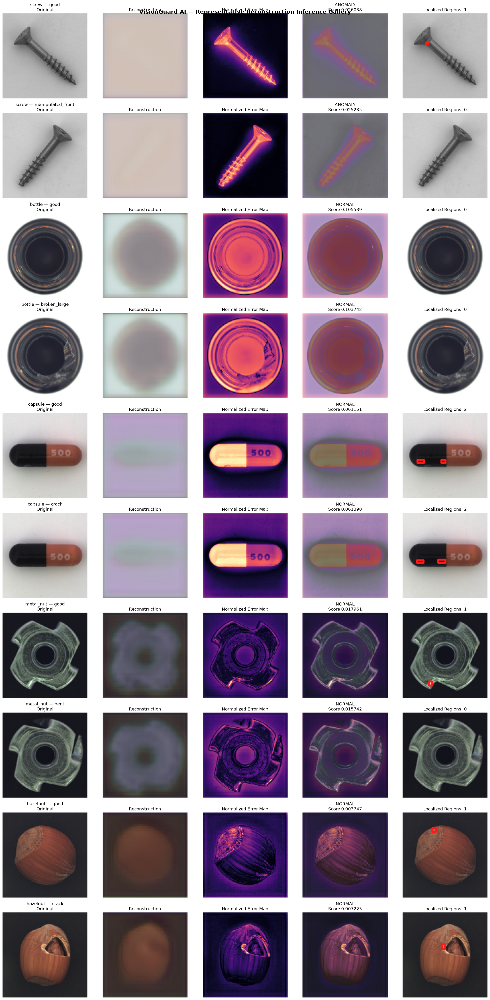

In [78]:
render_inference_gallery(
    demo_records
)


## Pixel-level threshold calibration


In [79]:
def calculate_pixel_threshold(category):
    values = []

    for image_path in validation_registry.get(
        category,
        [],
    ):
        _, _, metrics = predict_image(
            best_models[category],
            image_path,
        )

        values.extend(
            metrics["mae_map"].ravel()
        )

    if not values:
        return np.nan

    return float(
        np.percentile(
            np.asarray(values),
            PIXEL_THRESHOLD_PERCENTILE,
        )
    )


In [80]:
pixel_threshold_map = {
    category: calculate_pixel_threshold(category)
    for category in best_models
}

pixel_threshold_df = pd.DataFrame([
    {
        "Category": category,
        "Pixel Threshold": threshold,
        "Method": f"Normal calibration P{PIXEL_THRESHOLD_PERCENTILE:g}",
    }
    for category, threshold in pixel_threshold_map.items()
])

display(
    pixel_threshold_df.round(8)
)


2026-10-02 18:28:39.831181: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-02 18:28:44.850324: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

,Category,Pixel Threshold,Method
0,screw,0.540169,Normal calibration P99.5
1,bottle,0.567486,Normal calibration P99.5
2,capsule,0.581326,Normal calibration P99.5
3,metal_nut,0.328755,Normal calibration P99.5
4,hazelnut,0.187074,Normal calibration P99.5


In [81]:
fig = px.bar(
    pixel_threshold_df,
    x="Category",
    y="Pixel Threshold",
    text="Pixel Threshold",
    title="VisionGuard AI — Pixel Reconstruction Thresholds",
    template="plotly_white",
)

fig.update_traces(
    texttemplate="%{y:.6f}",
    textposition="outside",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Pixel Reconstruction Thresholds",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Defect localization analysis


In [82]:
localization_records = []

for record in demo_records:
    category = record["Category"]

    pixel_threshold = pixel_threshold_map.get(
        category,
        np.nan,
    )

    predicted_mask = binary_anomaly_mask(
        record["MAE Map"],
        pixel_threshold,
    )

    regions = bounding_regions(
        predicted_mask
    )

    overlap = pixel_overlap_metrics(
        predicted_mask,
        record["Ground Truth"],
    )

    localization_records.append({
        "Category": category,
        "Defect Type": record["Defect Type"],
        "File": record["File"],
        "Prediction": record["Prediction"],
        "Pixel Threshold": pixel_threshold,
        "Predicted Regions": len(regions),
        "Predicted Coverage (%)": float(
            predicted_mask.mean() * 100
        ),
        "Ground Truth Coverage (%)": (
            float(record["Ground Truth"].mean() * 100)
            if record["Ground Truth"] is not None
            else np.nan
        ),
        **overlap,
    })

localization_df = pd.DataFrame(
    localization_records
)

display(
    localization_df.round(4)
)


,Category,Defect Type,File,Prediction,Pixel Threshold,Predicted Regions,Predicted Coverage (%),Ground Truth Coverage (%),IoU,Dice,Pixel Precision,Pixel Recall,Pixel Accuracy
0,screw,good,000.png,ANOMALY,0.5402,1,0.0854,NaN,NaN,NaN,NaN,NaN,NaN
1,screw,manipulated_front,000.png,ANOMALY,0.5402,0,0.0000,0.3967,0.000,0.0000,0.0000,0.0000,0.9960
2,bottle,good,000.png,NORMAL,0.5675,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
3,bottle,broken_large,000.png,NORMAL,0.5675,0,0.0000,10.9009,0.000,0.0000,0.0000,0.0000,0.8910
4,capsule,good,000.png,NORMAL,0.5813,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
5,capsule,crack,000.png,NORMAL,0.5813,1,0.0732,0.2502,0.000,0.0000,0.0000,0.0000,0.9968
6,metal_nut,good,000.png,NORMAL,0.3288,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
7,metal_nut,bent,000.png,NORMAL,0.3288,0,0.0000,4.7058,0.000,0.0000,0.0000,0.0000,0.9529
8,hazelnut,good,000.png,NORMAL,0.1871,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
9,hazelnut,crack,000.png,NORMAL,0.1871,5,0.7507,6.3538,0.062,0.1168,0.5528,0.0653,0.9373


In [83]:
fig = px.scatter(
    localization_df,
    x="Ground Truth Coverage (%)",
    y="Predicted Coverage (%)",
    color="Category",
    symbol="Defect Type",
    title="VisionGuard AI — Predicted vs Ground-Truth Defect Coverage",
    template="plotly_white",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Predicted vs Ground-Truth Defect Coverage",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [84]:
pixel_summary_df = (
    localization_df
    .groupby("Category", as_index=False)
    .agg(
        Samples=("File", "count"),
        Mean_IoU=("IoU", "mean"),
        Mean_Dice=("Dice", "mean"),
        Mean_Precision=("Pixel Precision", "mean"),
        Mean_Recall=("Pixel Recall", "mean"),
    )
)

display(
    pixel_summary_df.round(4)
)


,Category,Samples,Mean_IoU,Mean_Dice,Mean_Precision,Mean_Recall
0,bottle,2,0.000,0.0000,0.0000,0.0000
1,capsule,2,0.000,0.0000,0.0000,0.0000
2,hazelnut,2,0.062,0.1168,0.5528,0.0653
3,metal_nut,2,0.000,0.0000,0.0000,0.0000
4,screw,2,0.000,0.0000,0.0000,0.0000


In [85]:
pixel_long_df = pixel_summary_df.melt(
    id_vars="Category",
    var_name="Metric",
    value_name="Value",
)

fig = px.bar(
    pixel_long_df,
    x="Category",
    y="Value",
    color="Metric",
    barmode="group",
    title="VisionGuard AI — Localization Quality Summary",
    template="plotly_white",
)

fig.update_yaxes(range=[0, 1])

finalize_plotly(
    fig,
    "VisionGuard AI — Localization Quality Summary",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

In [86]:
def render_localization_gallery(records):
    eligible = [
        record
        for record in records
        if record["Ground Truth"] is not None
    ]

    if not eligible:
        print("No representative images with ground-truth masks are available.")
        return

    rows = len(eligible)

    fig, axes = plt.subplots(
        rows,
        5,
        figsize=(20, 4.2 * rows),
        squeeze=False,
    )

    for row_index, record in enumerate(eligible):
        category = record["Category"]

        predicted_mask = binary_anomaly_mask(
            record["MAE Map"],
            pixel_threshold_map.get(
                category,
                np.percentile(
                    record["MAE Map"],
                    99,
                ),
            ),
        )

        regions = bounding_regions(
            predicted_mask
        )

        overlap = pixel_overlap_metrics(
            predicted_mask,
            record["Ground Truth"],
        )

        axes[row_index, 0].imshow(
            record["Image"]
        )
        axes[row_index, 0].set_title(
            f"{category}\n{record['Defect Type']}"
        )

        axes[row_index, 1].imshow(
            record["MAE Map"],
            cmap="magma",
        )
        axes[row_index, 1].set_title(
            "Error Map"
        )

        axes[row_index, 2].imshow(
            predicted_mask,
            cmap="gray",
        )
        axes[row_index, 2].set_title(
            "Predicted Mask"
        )

        axes[row_index, 3].imshow(
            record["Ground Truth"],
            cmap="gray",
        )
        axes[row_index, 3].set_title(
            "Ground Truth"
        )

        axes[row_index, 4].imshow(
            draw_regions(
                record["Image"],
                regions[:6],
            )
        )
        axes[row_index, 4].set_title(
            f"IoU {overlap['IoU']:.3f}\nDice {overlap['Dice']:.3f}"
        )

    for axis in axes.ravel():
        axis.axis("off")

    title = (
        "VisionGuard AI — Defect Localization Comparison Gallery"
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()
    finalize_mpl(fig, title)


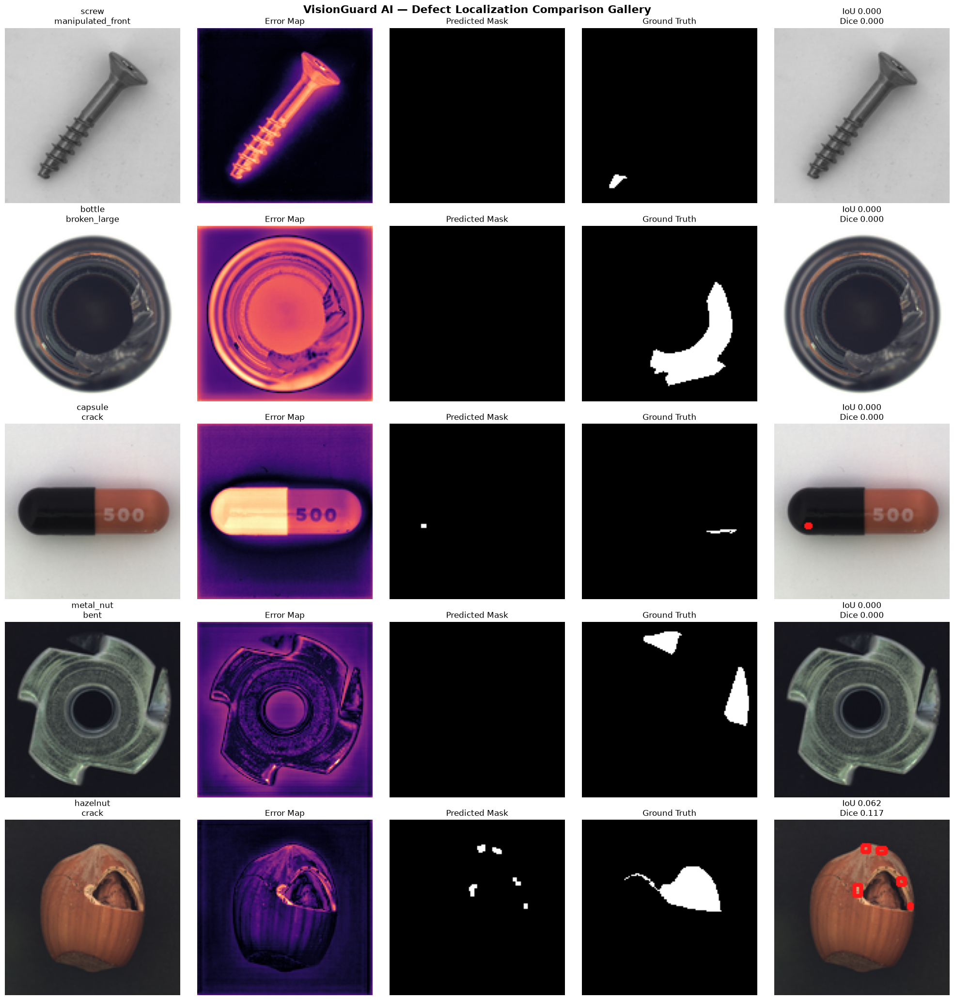

In [87]:
render_localization_gallery(
    demo_records
)


## Localization sensitivity and error analysis


In [88]:
morphology_record = next(
    (
        record
        for record in demo_records
        if record["Ground Truth"] is not None
        and record["Ground Truth Label"] == 1
    ),
    None,
)

print(
    "Defective sample selected for morphology analysis:",
    morphology_record is not None,
)


Defective sample selected for morphology analysis: True


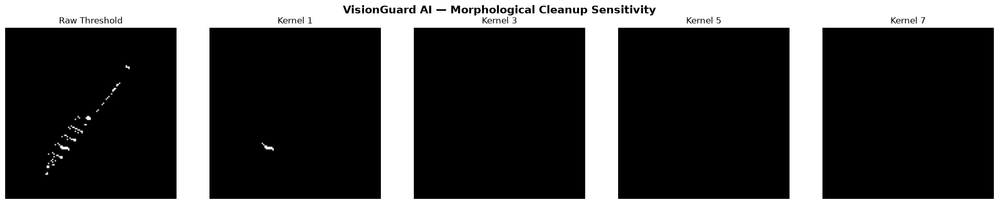

In [89]:
if morphology_record is not None:
    threshold = pixel_threshold_map.get(
        morphology_record["Category"],
        np.percentile(
            morphology_record["MAE Map"],
            99,
        ),
    )

    kernel_sizes = [1, 3, 5, 7]

    fig, axes = plt.subplots(
        1,
        len(kernel_sizes) + 1,
        figsize=(20, 4),
    )

    raw_mask = (
        morphology_record["MAE Map"]
        > threshold
    )

    axes[0].imshow(
        raw_mask,
        cmap="gray",
    )
    axes[0].set_title(
        "Raw Threshold"
    )

    for index, kernel_size in enumerate(
        kernel_sizes,
        start=1,
    ):
        cleaned = binary_anomaly_mask(
            morphology_record["MAE Map"],
            threshold,
            morphology_kernel=kernel_size,
            minimum_area=12,
        )

        axes[index].imshow(
            cleaned,
            cmap="gray",
        )
        axes[index].set_title(
            f"Kernel {kernel_size}"
        )

    for axis in axes:
        axis.axis("off")

    title = (
        "VisionGuard AI — Morphological Cleanup Sensitivity"
    )

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold",
    )

    plt.tight_layout()
    finalize_mpl(fig, title)


In [90]:
false_positive_df = score_results_df[
    (score_results_df["Ground Truth Label"].eq(0))
    & (
        score_results_df["Prediction"].eq("ANOMALY")
    )
].copy()

false_negative_df = score_results_df[
    (score_results_df["Ground Truth Label"].eq(1))
    & (
        score_results_df["Prediction"].eq("NORMAL")
    )
].copy()

print("False positives:", len(false_positive_df))
print("False negatives:", len(false_negative_df))


False positives: 27
False negatives: 435


In [91]:
fp_columns = [
    "Category",
    "Defect Type",
    "File",
    "Reconstruction Error",
    "Threshold",
    "Anomaly Margin",
]

display(
    false_positive_df[
        fp_columns
    ]
    .sort_values(
        "Anomaly Margin",
        ascending=False,
    )
    .head(15)
    .round(6)
)


,Category,Defect Type,File,Reconstruction Error,Threshold,Anomaly Margin
7,screw,good,007.png,0.030047,0.024788,0.005259
33,screw,good,033.png,0.029234,0.024788,0.004446
38,screw,good,038.png,0.028654,0.024788,0.003866
20,screw,good,020.png,0.028611,0.024788,0.003823
26,screw,good,026.png,0.027610,0.024788,0.002822
27,screw,good,027.png,0.027330,0.024788,0.002542
25,screw,good,025.png,0.027107,0.024788,0.002319
32,screw,good,032.png,0.026955,0.024788,0.002168
8,screw,good,008.png,0.026948,0.024788,0.002160
18,screw,good,018.png,0.026904,0.024788,0.002116


In [92]:
fn_columns = [
    "Category",
    "Defect Type",
    "File",
    "Reconstruction Error",
    "Threshold",
    "Anomaly Margin",
]

display(
    false_negative_df[
        fn_columns
    ]
    .sort_values(
        "Anomaly Margin",
        ascending=True,
    )
    .head(15)
    .round(6)
)


,Category,Defect Type,File,Reconstruction Error,Threshold,Anomaly Margin
439,metal_nut,flip,017.png,0.011385,0.026352,-0.014968
444,metal_nut,flip,022.png,0.012047,0.026352,-0.014305
214,bottle,contamination,012.png,0.093265,0.107541,-0.014276
364,capsule,squeeze,009.png,0.052247,0.066382,-0.014135
440,metal_nut,flip,018.png,0.012598,0.026352,-0.013754
208,bottle,contamination,006.png,0.093843,0.107541,-0.013698
373,capsule,squeeze,018.png,0.052834,0.066382,-0.013548
433,metal_nut,flip,011.png,0.012875,0.026352,-0.013477
370,capsule,squeeze,015.png,0.053086,0.066382,-0.013296
443,metal_nut,flip,021.png,0.013282,0.026352,-0.013070


In [93]:
error_type_df = (
    score_results_df
    .assign(
        Error_Type=np.select(
            [
                score_results_df["Correct"],
                (
                    score_results_df["Ground Truth Label"].eq(0)
                    & score_results_df["Prediction"].eq("ANOMALY")
                ),
                (
                    score_results_df["Ground Truth Label"].eq(1)
                    & score_results_df["Prediction"].eq("NORMAL")
                ),
            ],
            [
                "Correct",
                "False Positive",
                "False Negative",
            ],
            default="Other",
        )
    )
    .groupby(
        ["Category", "Error_Type"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Images"})
)

display(error_type_df)


,Category,Error_Type,Images
0,bottle,Correct,22
1,bottle,False Negative,61
2,capsule,Correct,25
3,capsule,False Negative,107
4,hazelnut,Correct,49
5,hazelnut,False Negative,61
6,metal_nut,Correct,22
7,metal_nut,False Negative,93
8,screw,Correct,20
9,screw,False Negative,113


In [94]:
fig = px.bar(
    error_type_df,
    x="Category",
    y="Images",
    color="Error_Type",
    barmode="stack",
    title="VisionGuard AI — Image-Level Error Analysis",
    template="plotly_white",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Image-Level Error Analysis",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Extreme anomaly-score examples


In [95]:
top_score_df = score_results_df.nlargest(
    5,
    "Reconstruction Error",
)

bottom_score_df = score_results_df.nsmallest(
    5,
    "Reconstruction Error",
)

display(
    top_score_df[
        [
            "Category",
            "Defect Type",
            "File",
            "Reconstruction Error",
            "Threshold",
            "Prediction",
        ]
    ].round(6)
)


,Category,Defect Type,File,Reconstruction Error,Threshold,Prediction
163,bottle,broken_large,003.png,0.108410,0.107541,ANOMALY
178,bottle,broken_large,018.png,0.107906,0.107541,ANOMALY
198,bottle,broken_small,018.png,0.107266,0.107541,NORMAL
220,bottle,contamination,018.png,0.107234,0.107541,NORMAL
161,bottle,broken_large,001.png,0.107088,0.107541,NORMAL


In [96]:
display(
    bottom_score_df[
        [
            "Category",
            "Defect Type",
            "File",
            "Reconstruction Error",
            "Threshold",
            "Prediction",
        ]
    ].round(6)
)


,Category,Defect Type,File,Reconstruction Error,Threshold,Prediction
552,hazelnut,good,027.png,0.003302,0.008426,NORMAL
515,hazelnut,cut,007.png,0.003311,0.008426,NORMAL
528,hazelnut,good,003.png,0.003326,0.008426,NORMAL
537,hazelnut,good,012.png,0.003439,0.008426,NORMAL
559,hazelnut,good,034.png,0.003444,0.008426,NORMAL


In [97]:
def fetch_demo_record(category, filename):
    for record in demo_records:
        if (
            record["Category"] == category
            and record["File"] == filename
        ):
            return record

    manifest_match = test_manifest_df[
        (
            test_manifest_df["Category"].eq(category)
            & test_manifest_df["File"].eq(filename)
        )
    ]

    if manifest_match.empty:
        return None

    row = manifest_match.iloc[0]

    image, reconstruction, metrics = predict_image(
        best_models[category],
        row["Image Path"],
    )

    record = result_row(
        category=category,
        defect_type=row["Defect Type"],
        file_name=row["File"],
        image_path=row["Image Path"],
        metrics=metrics,
    )

    record["Image"] = image
    record["Reconstruction"] = reconstruction
    record["MAE Map"] = metrics["mae_map"]
    record["Ground Truth"] = load_gray_mask(
        row["Ground Truth Path"]
    )

    return record


In [98]:
extreme_records = []

for frame in (
    top_score_df,
    bottom_score_df,
):
    for _, row in frame.iterrows():
        record = fetch_demo_record(
            row["Category"],
            row["File"],
        )

        if record is not None:
            extreme_records.append(record)


2026-10-02 18:29:11.699500: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


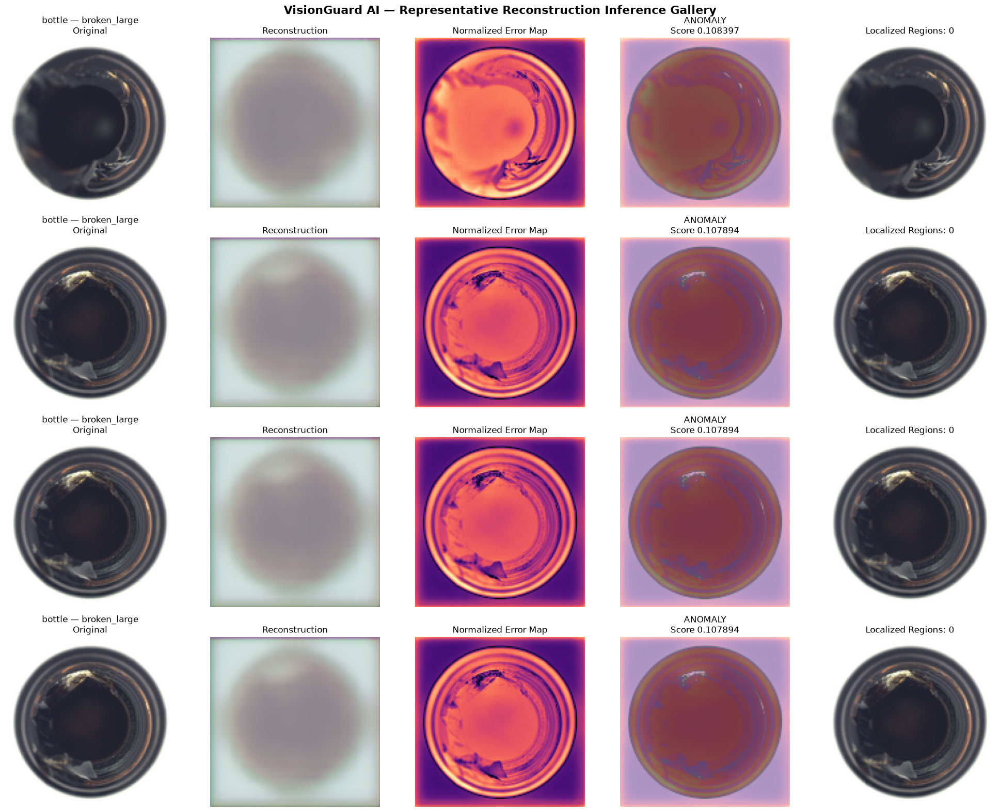

In [99]:
if extreme_records:
    render_inference_gallery(
        extreme_records[:DEMO_SAMPLE_LIMIT * 2]
    )
else:
    print("No extreme-score examples could be rendered.")


## Inference latency benchmark


In [100]:
timing_rows = []

for category, model in best_models.items():
    subset = test_manifest_df[
        test_manifest_df["Category"].eq(category)
    ].head(TIMING_SAMPLE_LIMIT)

    if subset.empty:
        continue

    warmup_image = load_rgb_array(
        subset.iloc[0]["Image Path"]
    )[None, ...]

    _ = model.predict(
        warmup_image,
        verbose=0,
    )

    images = [
        load_rgb_array(path)
        for path in subset["Image Path"]
    ]

    batch = np.stack(
        images,
        axis=0,
    )

    start = time.perf_counter()

    _ = model.predict(
        batch,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    image_count = len(images)

    timing_rows.append({
        "Category": category,
        "Images": image_count,
        "Total Seconds": elapsed,
        "Images / Second": (
            image_count / elapsed
            if elapsed > 0
            else np.nan
        ),
        "Milliseconds / Image": (
            elapsed * 1000 / image_count
            if image_count
            else np.nan
        ),
    })

timing_df = pd.DataFrame(
    timing_rows
)

display(
    timing_df.round(4)
)


2026-10-02 18:29:16.766040: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Category,Images,Total Seconds,Images / Second,Milliseconds / Image
0,screw,10,0.1331,75.1455,13.3075
1,bottle,10,0.0870,114.9004,8.7032
2,capsule,10,0.1408,71.0388,14.0768
3,metal_nut,10,0.0845,118.3663,8.4484
4,hazelnut,10,0.0814,122.9193,8.1354


In [101]:
fig = px.bar(
    timing_df,
    x="Category",
    y="Milliseconds / Image",
    text="Milliseconds / Image",
    title="VisionGuard AI — Batch Inference Latency by Category",
    template="plotly_white",
)

fig.update_traces(
    texttemplate="%{y:.2f} ms",
    textposition="outside",
)

finalize_plotly(
    fig,
    "VisionGuard AI — Batch Inference Latency by Category",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Optional runtime image inference

This section is optional. In Google Colab it opens the upload widget. The selected image is processed by the chosen category model.


In [102]:
colab_upload_available = colab_files is not None

print(
    "Colab upload support available:",
    colab_upload_available,
)


Colab upload support available: False


In [103]:
runtime_category = (
    available_categories[0]
    if available_categories
    else None
)

print(
    "Default runtime category:",
    runtime_category,
)


Default runtime category: screw


In [104]:
uploaded_runtime_names = []

if colab_upload_available:
    try:
        uploaded_runtime_names = list(
            colab_files.upload().keys()
        )
    except Exception:
        uploaded_runtime_names = []

print(
    "Runtime images received:",
    len(uploaded_runtime_names),
)


Runtime images received: 0


In [105]:
runtime_record = None

if (
    runtime_category in best_models
    and uploaded_runtime_names
):
    runtime_filename = uploaded_runtime_names[0]
    runtime_path = Path(runtime_filename)

    if (
        runtime_path.is_file()
        and is_image_file(runtime_path)
    ):
        image, reconstruction, metrics = predict_image(
            best_models[runtime_category],
            runtime_path,
        )

        runtime_record = result_row(
            category=runtime_category,
            defect_type="runtime_upload",
            file_name=runtime_path.name,
            image_path=runtime_path,
            metrics=metrics,
        )

        runtime_record["Image"] = image
        runtime_record["Reconstruction"] = reconstruction
        runtime_record["MAE Map"] = metrics["mae_map"]
        runtime_record["Ground Truth"] = None

print(
    "Runtime inference executed:",
    runtime_record is not None,
)


Runtime inference executed: False


In [106]:
if runtime_record is not None:
    runtime_summary_df = pd.DataFrame([
        {
            "Category": runtime_record["Category"],
            "Prediction": runtime_record["Prediction"],
            "Anomaly Score": runtime_record["Reconstruction Error"],
            "Threshold": runtime_record["Threshold"],
            "Threshold Ratio": runtime_record["Threshold Ratio"],
            "Anomaly Margin": runtime_record["Anomaly Margin"],
        }
    ])

    display(
        runtime_summary_df.round(6)
    )
else:
    print(
        "No runtime image was supplied. This optional section was skipped."
    )


No runtime image was supplied. This optional section was skipped.


In [107]:
if runtime_record is not None:
    category = runtime_record["Category"]

    threshold = pixel_threshold_map.get(
        category,
        np.percentile(
            runtime_record["MAE Map"],
            99,
        ),
    )

    predicted_mask = binary_anomaly_mask(
        runtime_record["MAE Map"],
        threshold,
    )

    regions = bounding_regions(
        predicted_mask
    )

    image = runtime_record["Image"]

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 4),
    )

    axes[0].imshow(image)
    axes[0].set_title("Uploaded Image")

    axes[1].imshow(
        runtime_record["Reconstruction"]
    )
    axes[1].set_title("Reconstruction")

    axes[2].imshow(
        runtime_record["MAE Map"],
        cmap="magma",
    )
    axes[2].set_title("Error Heatmap")

    axes[3].imshow(
        overlay_error_heatmap(
            image,
            runtime_record["MAE Map"],
        )
    )
    axes[3].set_title("Heatmap Overlay")

    axes[4].imshow(
        draw_regions(
            image,
            regions[:6],
        )
    )
    axes[4].set_title(
        f"Localized Regions: {len(regions)}"
    )

    for axis in axes:
        axis.axis("off")

    title = (
        f"VisionGuard AI — Runtime Inference — {category}"
    )

    fig.suptitle(
        f"{title} — {runtime_record['Prediction']}",
        fontsize=15,
        fontweight="bold",
    )

    plt.tight_layout()
    finalize_mpl(fig, title)


## Clean artifact exports


In [108]:
def clean_export_frame(frame):
    clean = frame.copy()

    path_columns = [
        column
        for column in clean.columns
        if "path" in str(column).strip().lower()
    ]

    if path_columns:
        clean = clean.drop(
            columns=path_columns
        )

    return clean


In [109]:
export_tables = {
    "inference_results.csv": score_results_df,
    "inference_metrics.csv": metrics_df,
    "inference_confusion_matrix.csv": confusion_df,
    "inference_thresholds.csv": threshold_df,
    "inference_pixel_thresholds.csv": pixel_threshold_df,
    "inference_localization.csv": localization_df,
    "inference_score_summary.csv": score_summary_df,
    "inference_threshold_sensitivity.csv": threshold_sensitivity_df,
    "inference_error_analysis.csv": error_type_df,
}

export_status_rows = []

for filename, frame in export_tables.items():
    output_frame = clean_export_frame(frame)
    output_frame.to_csv(
        TABLE_DIR / filename,
        index=False,
    )

    export_status_rows.append({
        "Artifact": filename,
        "Rows": len(output_frame),
        "Columns": len(output_frame.columns),
    })

export_status_df = pd.DataFrame(
    export_status_rows
)

display(export_status_df)


,Artifact,Rows,Columns
0,inference_results.csv,600,12
1,inference_metrics.csv,5,8
2,inference_confusion_matrix.csv,5,5
3,inference_thresholds.csv,5,3
4,inference_pixel_thresholds.csv,5,3
5,inference_localization.csv,10,13
6,inference_score_summary.csv,5,10
7,inference_threshold_sensitivity.csv,25,7
8,inference_error_analysis.csv,11,3


## Visualization artifact audit


In [110]:
png_files = sorted(
    IMAGE_DIR.glob("*.png")
)

html_files = sorted(
    IMAGE_DIR.glob("*.html")
)

visual_audit_df = pd.DataFrame({
    "Artifact Type": [
        "Static PNG",
        "Interactive Plotly HTML",
    ],
    "Count": [
        len(png_files),
        len(html_files),
    ],
})

display(
    visual_audit_df
)


,Artifact Type,Count
0,Static PNG,184
1,Interactive Plotly HTML,190


In [111]:
required_result_columns = {
    "Category",
    "Defect Type",
    "File",
    "Reconstruction Error",
    "Threshold",
    "Prediction",
}

integrity_checks = {
    "Inference results present": not score_results_df.empty,
    "Image thresholds present": not threshold_df.empty,
    "Loaded models present": bool(best_models),
    "Required result columns present": (
        required_result_columns.issubset(
            score_results_df.columns
        )
    ),
    "Visualization export helper available": (
        callable(finalize_mpl)
        and callable(finalize_plotly)
    ),
    "Tables exported": not export_status_df.empty,
}

integrity_df = pd.DataFrame([
    {
        "Check": check,
        "Passed": passed,
    }
    for check, passed in integrity_checks.items()
])

display(integrity_df)

if not integrity_df["Passed"].all():
    raise RuntimeError(
        "One or more inference integrity checks failed."
    )


,Check,Passed
0,Inference results present,True
1,Image thresholds present,True
2,Loaded models present,True
3,Required result columns present,True
4,Visualization export helper available,True
5,Tables exported,True


## Final category status


In [112]:
final_status_rows = []

for category in CATEGORIES:
    scored_count = int(
        (
            score_results_df["Category"].eq(category)
        ).sum()
    ) if not score_results_df.empty else 0

    final_status_rows.append({
        "Category": category,
        "Dataset Available": category in available_categories,
        "Model Loaded": category in best_models,
        "Threshold Available": category in threshold_map,
        "Samples Scored": scored_count,
    })

final_status_df = pd.DataFrame(
    final_status_rows
)

display(
    final_status_df
)


,Category,Dataset Available,Model Loaded,Threshold Available,Samples Scored
0,screw,True,True,True,160
1,bottle,True,True,True,83
2,capsule,True,True,True,132
3,metal_nut,True,True,True,115
4,hazelnut,True,True,True,110


In [113]:
ready_mask = (
    final_status_df["Dataset Available"].astype(bool)
    & final_status_df["Model Loaded"].astype(bool)
    & final_status_df["Threshold Available"].astype(bool)
)

ready_count = int(
    ready_mask.sum()
)

print(
    f"Inference-ready categories: {ready_count} of {len(CATEGORIES)}"
)

if ready_count == len(CATEGORIES):
    print(
        "VisionGuard AI inference workflow completed successfully."
    )
else:
    print(
        "VisionGuard AI inference workflow completed with unavailable categories."
    )


Inference-ready categories: 5 of 5
VisionGuard AI inference workflow completed successfully.


## Final dashboard


In [114]:
dashboard_metrics = metrics_df[
    [
        "Category",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
    ]
].melt(
    id_vars="Category",
    var_name="Metric",
    value_name="Score",
)

fig = px.bar(
    dashboard_metrics,
    x="Category",
    y="Score",
    color="Metric",
    barmode="group",
    title="VisionGuard AI — Final Image-Level Inference Dashboard",
    template="plotly_white",
)

fig.update_yaxes(
    range=[0, 1]
)

finalize_plotly(
    fig,
    "VisionGuard AI — Final Image-Level Inference Dashboard",
)


Plotly PNG export is unavailable in the current browser runtime.
Export warning: BrowserFailedError.


Plotly interactive figure exported; static PNG export needs browser support.


{'HTML': True, 'PNG': False}

## Inference interpretation guide

The reconstruction score measures the difference between an input image and its autoencoder reconstruction. A score above the category-specific threshold is classified as anomalous.

The anomaly margin is:

`reconstruction error − threshold`

The anomaly ratio is:

`reconstruction error ÷ threshold`

For defect localization, the pixel map is derived from the per-pixel reconstruction error, thresholded using normal calibration pixels, cleaned with morphological operations, and compared with the ground-truth mask where available.

ROC-AUC and Average Precision use the continuous reconstruction score rather than only the binary thresholded prediction.


## Notebook completion

All reusable imports are defined once, duplicate helper definitions have been removed, Plotly exports accept explicit width/height/scale arguments, timing uses `time.perf_counter()`, and the final status calculation uses a boolean mask followed by `.sum()`.

Every generated visualization is routed through the same export helpers so that PNG/HTML artifacts use their visualization title as the filename.
